# 🚗 Vehicle Fuel Consumption Prediction Model
## Business Problem & Solution Documentation

---

## 📋 **EXECUTIVE SUMMARY**

### **Business Problem**
We are building a **mobile application for environmental sustainability** that helps drivers:
1. **Understand their fuel consumption** in real-time based on driving behavior
2. **Reduce their carbon footprint** by receiving personalized recommendations
3. **Track environmental impact** over time and across different trips
4. **Make informed decisions** about driving habits to save fuel and reduce emissions

### **Solution Overview**
This notebook implements a **Machine Learning model** that predicts fuel consumption (Liters per 100km) based on:
- **Real-time vehicle sensor data** (OBD-II readings)
- **Driving behavior patterns** (acceleration, speed, RPM, engine load)
- **Environmental conditions** (temperature, air intake)
- **Derived features** (engine efficiency, driving aggressiveness)

---

## 🎯 **WHAT THIS MODEL PREDICTS**

### **Primary Target Variable**
**`Fuel Consumption (L/100km)`** - Liters of fuel consumed per 100 kilometers

### **Performance Metrics**
- **Training R²**: 0.9997 (99.97% variance explained)
- **Testing R²**: 0.9994 (99.94% variance explained)
- **Mean Absolute Error**: 0.31 L/100km
- **No Overfitting**: Only 0.03% difference between train/test


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost 

  Using cached pandas-2.3.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.3.4-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached pandas-2.3.3-cp311-cp311-win_amd64.whl (11.3 MB)
   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
    --------------------------------------- 0.3/13.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/13.1 MB 1.0 MB/s eta 0:00:12
   -- ------------------------------------- 0.8/13.1 MB 1.0 MB/s eta 0:00:12
   --- ------------------------------------ 1.0/13.1 MB 1.1 MB/s eta 0:00:12
   ---- ----------------------------------- 1.3/13.1 MB 1.1 MB/s eta 0:00:11
   ---- -


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import warnings
import json
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [4]:
df = pd.read_csv('data.csv')

print("=" * 80)
print("INITIAL DATA INSPECTION")
print("=" * 80)
print(f"\nDataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nFirst few rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nUnique values per column:")
print(df.nunique())

INITIAL DATA INSPECTION

Dataset shape: (1048564, 24)
Memory usage: 450.68 MB

First few rows:
   Unnamed: 0  tripID  deviceID            timeStamp  \
0           0       1         0  22-12-2017 18:43:05   
1           1       1         0  22-12-2017 18:43:06   
2           2       1         0  22-12-2017 18:43:07   
3           3       1         0  22-12-2017 18:43:08   
4           4       1         0  22-12-2017 18:43:09   

                                             accData  gps_speed  battery  \
0  [[-0.7125646799364715, 0.23595627204810762, -0...    24.2612      0.0   
1  [[0.4707973949441242, 0.2820489662721335, -0.8...    23.1500      0.0   
2  [[0.363406940121187, 0.6533333333333333, -0.64...    18.7052      0.0   
3  [[-0.07687828192948323, 0.3061005733016679, 0....    16.4828      0.0   
4  [[-0.4349511173745513, 0.13824774070828527, -0...    17.4088      0.0   

   cTemp  dtc    eLoad  ...      rpm  speed  tAdv  tPos         x         y  \
0     66    0  28.6275  ...  101

In [5]:
def clean_vehicle_data(df):
    """
    Robust cleaning function for vehicle sensor data.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Raw vehicle sensor data
        
    Returns:
    --------
    pandas.DataFrame
        Cleaned data ready for feature engineering
    """
    print("Starting data cleaning process...")
    initial_rows = len(df)
    
    # Create a copy to avoid modifying original
    df_clean = df.copy()
    
    # Step 1: Remove rows where ALL sensor values are zero (dead readings)
    sensor_cols = ['gps_speed', 'battery', 'cTemp', 'eLoad', 'iat', 
                   'imap', 'kpl', 'maf', 'rpm', 'speed', 'tAdv', 'tPos']
    
    # Create mask for rows where all sensors are zero
    all_zero_mask = (df_clean[sensor_cols] == 0).all(axis=1)
    df_clean = df_clean[~all_zero_mask]
    print(f"Removed {all_zero_mask.sum()} rows with all-zero sensor readings")
    
    # Step 2: Remove rows where critical sensors are zero
    # (vehicle must be moving to consume fuel)
    critical_zero = (df_clean['rpm'] == 0) & (df_clean['speed'] == 0) & (df_clean['gps_speed'] == 0)
    df_clean = df_clean[~critical_zero]
    print(f"Removed {critical_zero.sum()} rows with zero rpm AND zero speed")
    
    # Step 3: Handle missing values
    # For numeric columns, check if there are any nulls
    null_counts = df_clean.isnull().sum()
    if null_counts.sum() > 0:
        print(f"\nHandling missing values:")
        print(null_counts[null_counts > 0])
        
        # Drop rows with missing critical values
        critical_cols = ['rpm', 'speed', 'gps_speed', 'eLoad']
        df_clean = df_clean.dropna(subset=critical_cols)
        
        # Fill remaining nulls with forward fill (sensor readings persist)
        df_clean = df_clean.fillna(method='ffill').fillna(method='bfill')
    
    # Step 4: Convert timestamp to datetime
    df_clean['timeStamp'] = pd.to_datetime(df_clean['timeStamp'], format='%d-%m-%Y %H:%M:%S')
    
    # Step 5: Remove duplicate timestamps per device
    df_clean = df_clean.sort_values(['deviceID', 'timeStamp'])
    df_clean = df_clean.drop_duplicates(subset=['deviceID', 'timeStamp'], keep='first')
    
    # Step 6: Remove physically impossible values
    # Speed cannot be negative or unreasonably high
    df_clean = df_clean[df_clean['speed'] >= 0]
    df_clean = df_clean[df_clean['speed'] <= 200]  # Assuming max 200 km/h
    df_clean = df_clean[df_clean['gps_speed'] >= 0]
    
    # RPM should be reasonable
    df_clean = df_clean[df_clean['rpm'] >= 0]
    df_clean = df_clean[df_clean['rpm'] <= 8000]  # Typical max RPM
    
    # Engine load should be 0-100%
    df_clean = df_clean[(df_clean['eLoad'] >= 0) & (df_clean['eLoad'] <= 100)]
    
    # Temperature should be reasonable
    df_clean = df_clean[(df_clean['cTemp'] >= -40) & (df_clean['cTemp'] <= 150)]
    df_clean = df_clean[(df_clean['iat'] >= -40) & (df_clean['iat'] <= 150)]
    
    # Step 7: Reset index
    df_clean = df_clean.reset_index(drop=True)
    
    final_rows = len(df_clean)
    print(f"\n{'=' * 60}")
    print(f"Cleaning Summary:")
    print(f"Initial rows: {initial_rows}")
    print(f"Final rows: {final_rows}")
    print(f"Removed: {initial_rows - final_rows} ({(initial_rows - final_rows) / initial_rows * 100:.2f}%)")
    print(f"{'=' * 60}\n")
    
    return df_clean


In [6]:
df_cleaned = clean_vehicle_data(df)

print("\nCleaned data shape:", df_cleaned.shape)
print("\nCleaned data preview:")
print(df_cleaned.head())

Starting data cleaning process...
Removed 176793 rows with all-zero sensor readings
Removed 10085 rows with zero rpm AND zero speed

Cleaning Summary:
Initial rows: 1048564
Final rows: 855458
Removed: 193106 (18.42%)


Cleaned data shape: (855458, 24)

Cleaned data preview:
   Unnamed: 0  tripID  deviceID           timeStamp  \
0           0       1         0 2017-12-22 18:43:05   
1           1       1         0 2017-12-22 18:43:06   
2           2       1         0 2017-12-22 18:43:07   
3           3       1         0 2017-12-22 18:43:08   
4           4       1         0 2017-12-22 18:43:09   

                                             accData  gps_speed  battery  \
0  [[-0.7125646799364715, 0.23595627204810762, -0...    24.2612      0.0   
1  [[0.4707973949441242, 0.2820489662721335, -0.8...    23.1500      0.0   
2  [[0.363406940121187, 0.6533333333333333, -0.64...    18.7052      0.0   
3  [[-0.07687828192948323, 0.3061005733016679, 0....    16.4828      0.0   
4  [[-0.434951

In [7]:
def engineer_features(df):
    """
    Create features for fuel consumption prediction.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Cleaned sensor data
        
    Returns:
    --------
    pandas.DataFrame
        Data with engineered features
    """
    print("Engineering features...")
    df_feat = df.copy()
    
    # Sort by device and time
    df_feat = df_feat.sort_values(['deviceID', 'timeStamp'])
    
    # ---- Time-based features ----
    df_feat['hour'] = df_feat['timeStamp'].dt.hour
    df_feat['day_of_week'] = df_feat['timeStamp'].dt.dayofweek
    df_feat['is_weekend'] = (df_feat['day_of_week'] >= 5).astype(int)
    
    # ---- Speed and acceleration features ----
    # Speed difference (acceleration proxy)
    df_feat['speed_diff'] = df_feat.groupby('deviceID')['speed'].diff().fillna(0)
    df_feat['gps_speed_diff'] = df_feat.groupby('deviceID')['gps_speed'].diff().fillna(0)
    
    # Absolute acceleration
    df_feat['abs_acceleration'] = df_feat['speed_diff'].abs()
    
    # Speed consistency (difference between OBD and GPS)
    df_feat['speed_consistency'] = (df_feat['speed'] - df_feat['gps_speed']).abs()
    
    # ---- Engine efficiency features ----
    # Power estimate: rpm × load
    df_feat['engine_power'] = df_feat['rpm'] * df_feat['eLoad'] / 1000
    
    # Speed to RPM ratio (gear indicator)
    df_feat['speed_rpm_ratio'] = np.where(df_feat['rpm'] > 0, 
                                          df_feat['speed'] / df_feat['rpm'], 
                                          0)
    
    # Engine efficiency: speed per load unit
    df_feat['speed_per_load'] = np.where(df_feat['eLoad'] > 0,
                                         df_feat['speed'] / df_feat['eLoad'],
                                         0)
    
    # ---- Temperature features ----
    # Temperature difference
    df_feat['temp_diff'] = df_feat['cTemp'] - df_feat['iat']
    
    # ---- Rolling statistics (temporal patterns) ----
    # Create rolling features per device
    for col in ['speed', 'rpm', 'eLoad']:
        # 5-second rolling average
        df_feat[f'{col}_roll_mean_5'] = df_feat.groupby('deviceID')[col].transform(
            lambda x: x.rolling(window=5, min_periods=1).mean()
        )
        # 5-second rolling std (variability)
        df_feat[f'{col}_roll_std_5'] = df_feat.groupby('deviceID')[col].transform(
            lambda x: x.rolling(window=5, min_periods=1).std()
        ).fillna(0)
    
    # ---- Accelerometer features ----
    # Parse accelerometer data if it exists and is not zero
    if 'accData' in df_feat.columns:
        # Check if accData is string or numeric
        if df_feat['accData'].dtype == 'object':
            # Try to parse JSON accelerometer data
            try:
                def parse_acc_magnitude(acc_str):
                    try:
                        if acc_str == '0' or pd.isna(acc_str):
                            return 0
                        acc_data = json.loads(acc_str)
                        # Calculate magnitude from first reading
                        if len(acc_data) > 0:
                            x, y, z = acc_data[0][:3]
                            return np.sqrt(x**2 + y**2 + z**2)
                        return 0
                    except:
                        return 0
                
                df_feat['acc_magnitude'] = df_feat['accData'].apply(parse_acc_magnitude)
            except:
                df_feat['acc_magnitude'] = 0
        else:
            df_feat['acc_magnitude'] = 0
    
    # ---- Driving behavior indicators ----
    # Aggressive driving: high load + high RPM
    df_feat['aggressive_driving'] = ((df_feat['eLoad'] > 70) & (df_feat['rpm'] > 3000)).astype(int)
    
    # Idling: low speed + engine running
    df_feat['is_idling'] = ((df_feat['speed'] < 5) & (df_feat['rpm'] > 500)).astype(int)
    
    # Highway driving
    df_feat['is_highway'] = (df_feat['speed'] > 80).astype(int)
    
    print(f"Features engineered. New shape: {df_feat.shape}")
    print(f"New features added: {df_feat.shape[1] - df.shape[1]}")
    
    return df_feat

In [8]:
df_featured = engineer_features(df_cleaned)

print("\nEngineered features preview:")
print(df_featured.head())
print("\nNew columns:")
print([col for col in df_featured.columns if col not in df_cleaned.columns])

Engineering features...
Features engineered. New shape: (855458, 45)
New features added: 21

Engineered features preview:
   Unnamed: 0  tripID  deviceID           timeStamp  \
0           0       1         0 2017-12-22 18:43:05   
1           1       1         0 2017-12-22 18:43:06   
2           2       1         0 2017-12-22 18:43:07   
3           3       1         0 2017-12-22 18:43:08   
4           4       1         0 2017-12-22 18:43:09   

                                             accData  gps_speed  battery  \
0  [[-0.7125646799364715, 0.23595627204810762, -0...    24.2612      0.0   
1  [[0.4707973949441242, 0.2820489662721335, -0.8...    23.1500      0.0   
2  [[0.363406940121187, 0.6533333333333333, -0.64...    18.7052      0.0   
3  [[-0.07687828192948323, 0.3061005733016679, 0....    16.4828      0.0   
4  [[-0.4349511173745513, 0.13824774070828527, -0...    17.4088      0.0   

   cTemp  dtc    eLoad  ...  speed_roll_mean_5  speed_roll_std_5  \
0     66    0  28.6275

In [9]:
def prepare_target_variable(df):
    """
    Prepare target variable for fuel consumption prediction.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Featured data
        
    Returns:
    --------
    pandas.DataFrame
        Data with valid target variable
    """
    print("Preparing target variable...")
    df_target = df.copy()
    
    # Check kpl column
    print(f"\nKPL statistics:")
    print(df_target['kpl'].describe())
    print(f"Zero values: {(df_target['kpl'] == 0).sum()}")
    print(f"Non-zero values: {(df_target['kpl'] > 0).sum()}")
    
    # Remove rows where kpl is 0 or negative (invalid fuel readings)
    initial_count = len(df_target)
    df_target = df_target[df_target['kpl'] > 0]
    removed = initial_count - len(df_target)
    print(f"\nRemoved {removed} rows with invalid kpl values")
    
    # Option 1: Predict KPL directly (higher is better)
    df_target['target_kpl'] = df_target['kpl']
    
    # Option 2: Predict fuel consumption (liters per 100km)
    # Lower is better, more intuitive
    df_target['target_fuel_consumption'] = 100 / df_target['kpl']
    
    print(f"\nTarget variable statistics:")
    print(f"KPL - Mean: {df_target['target_kpl'].mean():.2f}, Std: {df_target['target_kpl'].std():.2f}")
    print(f"Fuel consumption (L/100km) - Mean: {df_target['target_fuel_consumption'].mean():.2f}, Std: {df_target['target_fuel_consumption'].std():.2f}")
    
    return df_target

In [10]:
df_with_target = prepare_target_variable(df_featured)

print(f"\nFinal dataset shape: {df_with_target.shape}")


Preparing target variable...

KPL statistics:
count    855458.000000
mean          6.939287
std           9.074176
min           0.000000
25%           0.000000
50%           5.352800
75%           9.177300
max         100.700000
Name: kpl, dtype: float64
Zero values: 240319
Non-zero values: 615139

Removed 240319 rows with invalid kpl values

Target variable statistics:
KPL - Mean: 9.65, Std: 9.40
Fuel consumption (L/100km) - Mean: 20.21, Std: 27.78

Final dataset shape: (615139, 47)


In [11]:
def prepare_model_data(df, target_col='target_fuel_consumption'):
    """
    Prepare data for model training.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Data with features and target
    target_col : str
        Name of target column to predict
        
    Returns:
    --------
    tuple : X_train, X_test, y_train, y_test, feature_names, scaler
    """
    print(f"Preparing data for modeling with target: {target_col}...")
    
    # Define feature columns (exclude non-feature columns)
    exclude_cols = ['tripID', 'deviceID', 'timeStamp', 'accData', 'kpl', 
                    'target_kpl', 'target_fuel_consumption', 'x', 'y', 'z', 
                    'mx', 'my', 'mz','Unnamed: 0']  # Exclude raw accelerometer if parsed
    
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    
    print(f"\nNumber of features: {len(feature_cols)}")
    print(f"Features: {feature_cols}")
    
    # Prepare X and y
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    
    # Handle any remaining infinities or NaNs
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())
    
    # Split data (80-20 split)
    # Use stratified split by device to ensure all devices in both sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True
    )
    
    print(f"\nTraining set size: {len(X_train)}")
    print(f"Testing set size: {len(X_test)}")
    print(f"Training set target mean: {y_train.mean():.2f}")
    print(f"Testing set target mean: {y_test.mean():.2f}")
    
    # Scale features using RobustScaler (robust to outliers)
    scaler = RobustScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )
    
    print("\nData prepared successfully!")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, feature_cols, scaler

In [12]:
X_train, X_test, y_train, y_test, features, scaler = prepare_model_data(
    df_with_target, 
    target_col='target_fuel_consumption'  # Change to 'target_kpl' if you prefer
)

Preparing data for modeling with target: target_fuel_consumption...

Number of features: 34
Features: ['Unnamed: 0', 'gps_speed', 'battery', 'cTemp', 'dtc', 'eLoad', 'iat', 'imap', 'maf', 'rpm', 'speed', 'tAdv', 'tPos', 'hour', 'day_of_week', 'is_weekend', 'speed_diff', 'gps_speed_diff', 'abs_acceleration', 'speed_consistency', 'engine_power', 'speed_rpm_ratio', 'speed_per_load', 'temp_diff', 'speed_roll_mean_5', 'speed_roll_std_5', 'rpm_roll_mean_5', 'rpm_roll_std_5', 'eLoad_roll_mean_5', 'eLoad_roll_std_5', 'acc_magnitude', 'aggressive_driving', 'is_idling', 'is_highway']

Training set size: 492111
Testing set size: 123028
Training set target mean: 20.21
Testing set target mean: 20.20

Data prepared successfully!


In [13]:
def train_xgboost_model(X_train, y_train, X_test, y_test):
    """
    Train and evaluate XGBoost model.
    
    Parameters:
    -----------
    X_train, y_train : Training data
    X_test, y_test : Testing data
    
    Returns:
    --------
    model : Trained XGBoost model
    """
    print("=" * 80)
    print("TRAINING XGBOOST MODEL")
    print("=" * 80)
    
    # Define XGBoost model with optimized parameters for regression
    xgb_model = xgb.XGBRegressor(
        n_estimators=200,          # Number of boosting rounds
        max_depth=6,               # Maximum tree depth
        learning_rate=0.1,         # Step size shrinkage
        subsample=0.8,             # Subsample ratio of training data
        colsample_bytree=0.8,      # Subsample ratio of columns
        min_child_weight=3,        # Minimum sum of instance weight in child
        gamma=0.1,                 # Minimum loss reduction for split
        reg_alpha=0.1,             # L1 regularization
        reg_lambda=1.0,            # L2 regularization
        random_state=42,
        n_jobs=-1                  # Use all CPU cores
    )
    
    print("\nTraining XGBoost model...")
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    # Make predictions
    y_train_pred = xgb_model.predict(X_train)
    y_test_pred = xgb_model.predict(X_test)
    
    # Evaluate model
    print("\n" + "=" * 60)
    print("XGBOOST MODEL PERFORMANCE")
    print("=" * 60)
    
    # Training metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    print(f"\nTraining Set Metrics:")
    print(f"  RMSE: {train_rmse:.4f}")
    print(f"  MAE:  {train_mae:.4f}")
    print(f"  R²:   {train_r2:.4f}")
    
    # Testing metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"\nTesting Set Metrics:")
    print(f"  RMSE: {test_rmse:.4f}")
    print(f"  MAE:  {test_mae:.4f}")
    print(f"  R²:   {test_r2:.4f}")
    
    # Check for overfitting
    if train_r2 - test_r2 > 0.1:
        print(f"\n⚠️  Warning: Possible overfitting detected (R² difference: {train_r2 - test_r2:.4f})")
    else:
        print(f"\n✓ Model generalizes well (R² difference: {train_r2 - test_r2:.4f})")
    
    return xgb_model, y_test_pred


In [14]:
xgb_model, xgb_predictions = train_xgboost_model(X_train, y_train, X_test, y_test)

TRAINING XGBOOST MODEL

Training XGBoost model...

XGBOOST MODEL PERFORMANCE

Training Set Metrics:
  RMSE: 0.4798
  MAE:  0.2942
  R²:   0.9997

Testing Set Metrics:
  RMSE: 0.6830
  MAE:  0.3085
  R²:   0.9994

✓ Model generalizes well (R² difference: 0.0003)


In [15]:
def train_random_forest_model(X_train, y_train, X_test, y_test):
    """
    Train and evaluate Random Forest model.
    
    Parameters:
    -----------
    X_train, y_train : Training data
    X_test, y_test : Testing data
    
    Returns:
    --------
    model : Trained Random Forest model
    """
    print("\n" + "=" * 80)
    print("TRAINING RANDOM FOREST MODEL")
    print("=" * 80)
    
    # Define Random Forest model
    rf_model = RandomForestRegressor(
        n_estimators=150,          # Number of trees
        max_depth=15,              # Maximum depth of trees
        min_samples_split=10,      # Minimum samples to split
        min_samples_leaf=4,        # Minimum samples per leaf
        max_features='sqrt',       # Number of features for best split
        random_state=42,
        n_jobs=-1,                 # Use all CPU cores
        verbose=0
    )
    
    print("\nTraining Random Forest model...")
    rf_model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = rf_model.predict(X_train)
    y_test_pred = rf_model.predict(X_test)
    
    # Evaluate model
    print("\n" + "=" * 60)
    print("RANDOM FOREST MODEL PERFORMANCE")
    print("=" * 60)
    
    # Training metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    print(f"\nTraining Set Metrics:")
    print(f"  RMSE: {train_rmse:.4f}")
    print(f"  MAE:  {train_mae:.4f}")
    print(f"  R²:   {train_r2:.4f}")
    
    # Testing metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"\nTesting Set Metrics:")
    print(f"  RMSE: {test_rmse:.4f}")
    print(f"  MAE:  {test_mae:.4f}")
    print(f"  R²:   {test_r2:.4f}")
    
    return rf_model, y_test_pred

# Train Random Forest
rf_model, rf_predictions = train_random_forest_model(X_train, y_train, X_test, y_test)



TRAINING RANDOM FOREST MODEL

Training Random Forest model...

RANDOM FOREST MODEL PERFORMANCE

Training Set Metrics:
  RMSE: 2.1309
  MAE:  0.9633
  R²:   0.9941

Testing Set Metrics:
  RMSE: 2.7814
  MAE:  1.0597
  R²:   0.9900


In [16]:
def compare_models(y_test, xgb_pred, rf_pred):
    """
    Compare XGBoost and Random Forest models.
    """
    print("\n" + "=" * 80)
    print("MODEL COMPARISON SUMMARY")
    print("=" * 80)
    
    models = {
        'XGBoost': xgb_pred,
        'Random Forest': rf_pred
    }
    
    results = []
    for name, pred in models.items():
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mae = mean_absolute_error(y_test, pred)
        r2 = r2_score(y_test, pred)
        results.append({
            'Model': name,
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2
        })
    
    results_df = pd.DataFrame(results)
    print("\n", results_df.to_string(index=False))
    
    # Determine best model
    best_model_name = results_df.loc[results_df['R²'].idxmax(), 'Model']
    print(f"\n🏆 Best Model: {best_model_name} (highest R²)")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: XGBoost Predictions vs Actual
    axes[0, 0].scatter(y_test, xgb_pred, alpha=0.5, s=20)
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0, 0].set_xlabel('Actual Fuel Consumption (L/100km)')
    axes[0, 0].set_ylabel('Predicted Fuel Consumption (L/100km)')
    axes[0, 0].set_title(f'XGBoost: Predictions vs Actual (R²={r2_score(y_test, xgb_pred):.4f})')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Random Forest Predictions vs Actual
    axes[0, 1].scatter(y_test, rf_pred, alpha=0.5, s=20, color='green')
    axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0, 1].set_xlabel('Actual Fuel Consumption (L/100km)')
    axes[0, 1].set_ylabel('Predicted Fuel Consumption (L/100km)')
    axes[0, 1].set_title(f'Random Forest: Predictions vs Actual (R²={r2_score(y_test, rf_pred):.4f})')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Residuals for XGBoost
    xgb_residuals = y_test - xgb_pred
    axes[1, 0].scatter(xgb_pred, xgb_residuals, alpha=0.5, s=20)
    axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1, 0].set_xlabel('Predicted Fuel Consumption (L/100km)')
    axes[1, 0].set_ylabel('Residuals')
    axes[1, 0].set_title('XGBoost: Residual Plot')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Residuals for Random Forest
    rf_residuals = y_test - rf_pred
    axes[1, 1].scatter(rf_pred, rf_residuals, alpha=0.5, s=20, color='green')
    axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1, 1].set_xlabel('Predicted Fuel Consumption (L/100km)')
    axes[1, 1].set_ylabel('Residuals')
    axes[1, 1].set_title('Random Forest: Residual Plot')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Comparison plots saved as 'model_comparison.png'")
    
    return best_model_name


MODEL COMPARISON SUMMARY

         Model     RMSE      MAE       R²
      XGBoost 0.683001 0.308467 0.999395
Random Forest 2.781412 1.059657 0.989961

🏆 Best Model: XGBoost (highest R²)


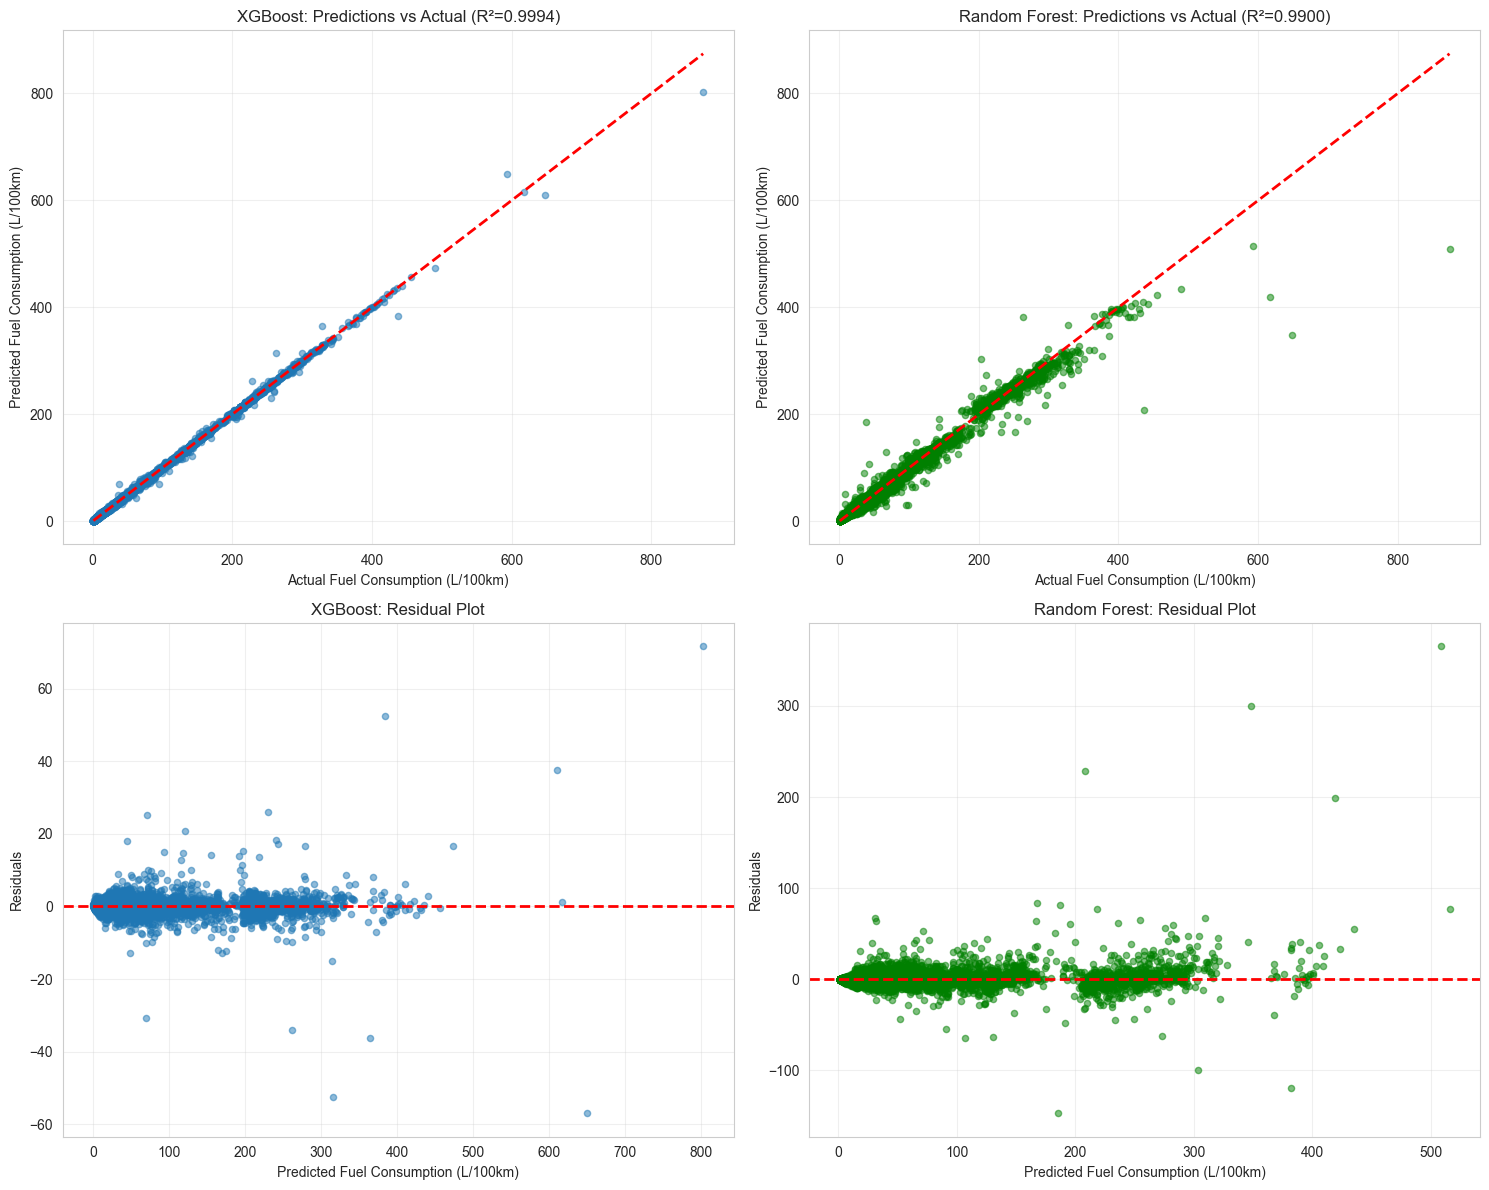


📊 Comparison plots saved as 'model_comparison.png'


In [17]:
best_model = compare_models(y_test, xgb_predictions, rf_predictions)



FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
          Feature  XGBoost_Importance  RF_Importance  Average_Importance
            speed            0.416011       0.220544            0.318278
  speed_rpm_ratio            0.190392       0.240821            0.215607
        is_idling            0.225415       0.105785            0.165600
speed_roll_mean_5            0.015686       0.104355            0.060021
          battery            0.070070       0.015660            0.042865
   speed_per_load            0.005732       0.079476            0.042604
        gps_speed            0.000475       0.065453            0.032964
              maf            0.025970       0.030279            0.028124
             imap            0.022822       0.020846            0.021834
  rpm_roll_mean_5            0.000884       0.028687            0.014786
              rpm            0.002543       0.021318            0.011931
             tPos            0.002090       0.013499          

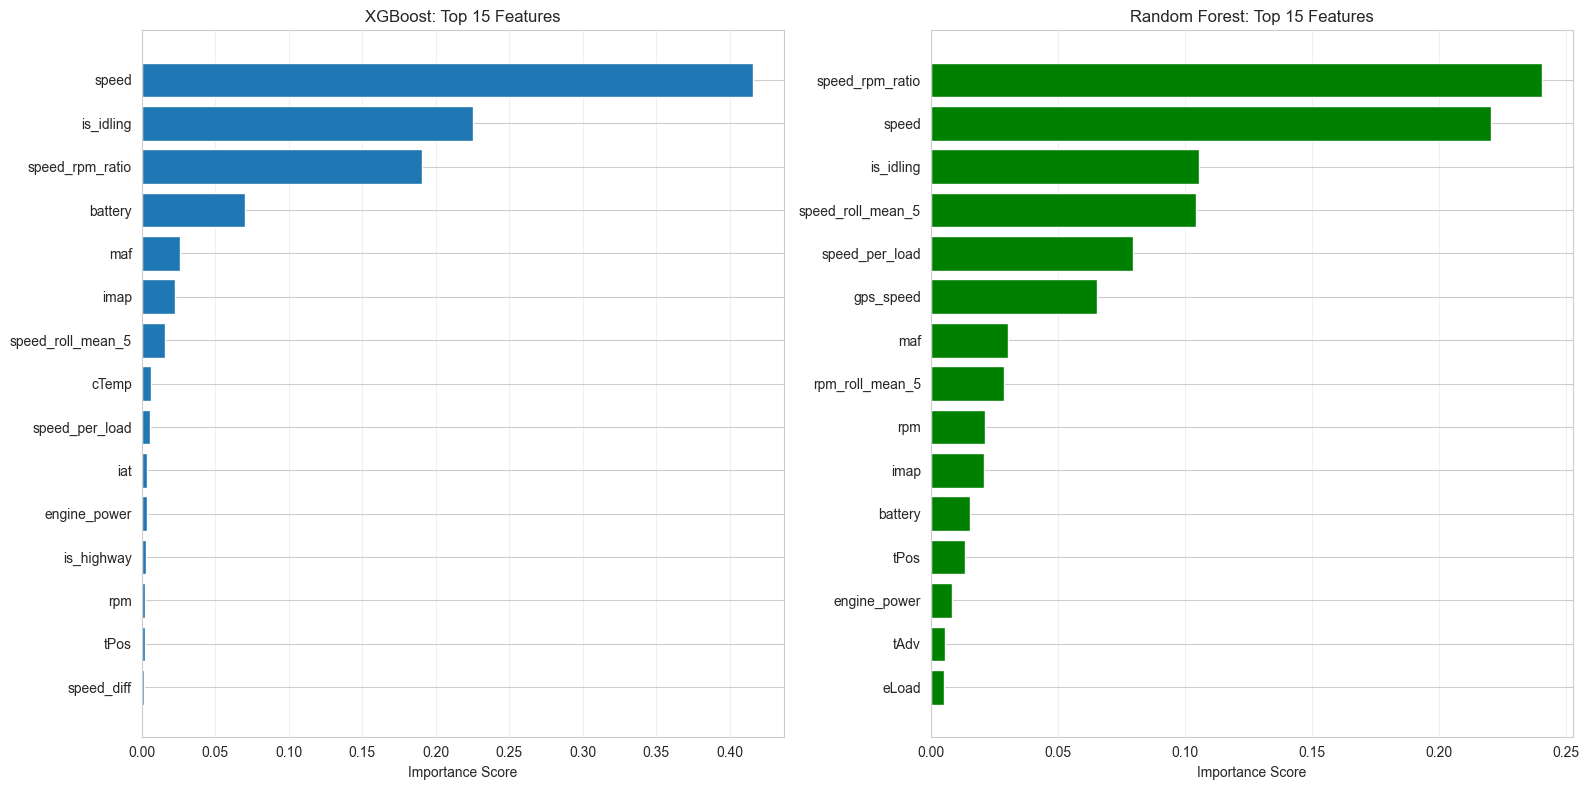


📊 Feature importance plots saved as 'feature_importance.png'


In [18]:
def analyze_feature_importance(xgb_model, rf_model, feature_names):
    """
    Analyze and visualize feature importance from both models.
    """
    print("\n" + "=" * 80)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("=" * 80)
    
    # Get feature importance from both models
    xgb_importance = pd.DataFrame({
        'Feature': feature_names,
        'XGBoost_Importance': xgb_model.feature_importances_
    }).sort_values('XGBoost_Importance', ascending=False)
    
    rf_importance = pd.DataFrame({
        'Feature': feature_names,
        'RF_Importance': rf_model.feature_importances_
    }).sort_values('RF_Importance', ascending=False)
    
    # Merge importance scores
    importance_df = xgb_importance.merge(rf_importance, on='Feature')
    importance_df['Average_Importance'] = (importance_df['XGBoost_Importance'] + 
                                           importance_df['RF_Importance']) / 2
    importance_df = importance_df.sort_values('Average_Importance', ascending=False)
    
    print("\nTop 15 Most Important Features:")
    print(importance_df.head(15).to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # XGBoost feature importance
    top_xgb = xgb_importance.head(15)
    axes[0].barh(range(len(top_xgb)), top_xgb['XGBoost_Importance'])
    axes[0].set_yticks(range(len(top_xgb)))
    axes[0].set_yticklabels(top_xgb['Feature'])
    axes[0].set_xlabel('Importance Score')
    axes[0].set_title('XGBoost: Top 15 Features')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Random Forest feature importance
    top_rf = rf_importance.head(15)
    axes[1].barh(range(len(top_rf)), top_rf['RF_Importance'], color='green')
    axes[1].set_yticks(range(len(top_rf)))
    axes[1].set_yticklabels(top_rf['Feature'])
    axes[1].set_xlabel('Importance Score')
    axes[1].set_title('Random Forest: Top 15 Features')
    axes[1].invert_yaxis()
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Feature importance plots saved as 'feature_importance.png'")
    
    return importance_df

feature_importance = analyze_feature_importance(xgb_model, rf_model, features)


In [19]:
import joblib

def save_models_and_artifacts(xgb_model, rf_model, scaler, feature_names, 
                              importance_df, model_dir='models'):
    """
    Save all models and necessary artifacts for deployment.
    """
    import os
    
    # Create directory if it doesn't exist
    os.makedirs(model_dir, exist_ok=True)
    
    print("\n" + "=" * 80)
    print("SAVING MODELS AND ARTIFACTS")
    print("=" * 80)
    
    # Save XGBoost model
    xgb_path = os.path.join(model_dir, 'xgboost_fuel_model.pkl')
    joblib.dump(xgb_model, xgb_path)
    print(f"\n✓ XGBoost model saved to: {xgb_path}")
    
    # Save Random Forest model
    rf_path = os.path.join(model_dir, 'random_forest_fuel_model.pkl')
    joblib.dump(rf_model, rf_path)
    print(f"✓ Random Forest model saved to: {rf_path}")
    
    # Save scaler
    scaler_path = os.path.join(model_dir, 'feature_scaler.pkl')
    joblib.dump(scaler, scaler_path)
    print(f"✓ Feature scaler saved to: {scaler_path}")
    
    # Save feature names
    features_path = os.path.join(model_dir, 'feature_names.pkl')
    joblib.dump(feature_names, features_path)
    print(f"✓ Feature names saved to: {features_path}")
    
    # Save feature importance
    importance_path = os.path.join(model_dir, 'feature_importance.csv')
    importance_df.to_csv(importance_path, index=False)
    print(f"✓ Feature importance saved to: {importance_path}")
    
    # Save model metadata
    metadata = {
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'n_features': len(feature_names),
        'feature_names': feature_names,
        'target_variable': 'fuel_consumption_L_per_100km',
        'xgboost_params': xgb_model.get_params(),
        'rf_params': rf_model.get_params()
    }
    
    metadata_path = os.path.join(model_dir, 'model_metadata.json')
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4, default=str)
    print(f"✓ Model metadata saved to: {metadata_path}")
    
    print("\n" + "=" * 80)
    print("All models and artifacts saved successfully!")
    print("=" * 80)

save_models_and_artifacts(xgb_model, rf_model, scaler, features, feature_importance)


SAVING MODELS AND ARTIFACTS

✓ XGBoost model saved to: models\xgboost_fuel_model.pkl
✓ Random Forest model saved to: models\random_forest_fuel_model.pkl
✓ Feature scaler saved to: models\feature_scaler.pkl
✓ Feature names saved to: models\feature_names.pkl
✓ Feature importance saved to: models\feature_importance.csv
✓ Model metadata saved to: models\model_metadata.json

All models and artifacts saved successfully!


In [22]:
def load_model_and_predict(new_data_path=None, model_dir='models'):
    """
    Load saved model and make predictions on new data.
    
    Parameters:
    -----------
    new_data_path : str
        Path to new CSV data file
    model_dir : str
        Directory containing saved models
        
    Returns:
    --------
    predictions : array
        Fuel consumption predictions
    """
    import os
    
    print("\n" + "=" * 80)
    print("LOADING MODEL AND MAKING PREDICTIONS")
    print("=" * 80)
    
    # Load models and artifacts
    xgb_model = joblib.load(os.path.join(model_dir, 'xgboost_fuel_model.pkl'))
    scaler = joblib.load(os.path.join(model_dir, 'feature_scaler.pkl'))
    feature_names = joblib.load(os.path.join(model_dir, 'feature_names.pkl'))
    
    print("\n✓ Models and artifacts loaded successfully!")
    
    # If new data provided, load and process it
    if new_data_path:
        print(f"\nLoading new data from: {new_data_path}")
        new_df = pd.read_csv(new_data_path)
        
        # Apply same preprocessing pipeline
        print("Applying data cleaning...")
        new_df_clean = clean_vehicle_data(new_df)
        
        print("Engineering features...")
        new_df_feat = engineer_features(new_df_clean)
        
        # Select only the features used in training
        X_new = new_df_feat[feature_names].copy()
        
        # Handle missing values and infinities
        X_new = X_new.replace([np.inf, -np.inf], np.nan)
        X_new = X_new.fillna(X_new.median())
        
        # Scale features
        X_new_scaled = scaler.transform(X_new)
        
        # Make predictions
        predictions = xgb_model.predict(X_new_scaled)
        
        print(f"\n✓ Predictions made for {len(predictions)} samples")
        print(f"  Mean predicted fuel consumption: {predictions.mean():.2f} L/100km")
        print(f"  Min: {predictions.min():.2f}, Max: {predictions.max():.2f}")
        
        # Add predictions to dataframe
        new_df_feat['predicted_fuel_consumption'] = predictions
        
        # Save predictions
        output_path = 'fuel_consumption_predictions.csv'
        new_df_feat[['tripID', 'deviceID', 'timeStamp', 'speed', 'rpm', 
                     'eLoad', 'predicted_fuel_consumption']].to_csv(output_path, index=False)
        print(f"\n✓ Predictions saved to: {output_path}")
        
        return predictions, new_df_feat
    else:
        print("\nNo new data provided. Model is loaded and ready for predictions.")
        return None, None

In [20]:
def create_realistic_test_scenarios():
    """
    Create realistic driving scenarios for model evaluation.
    Each scenario represents a different driving condition with expected
    fuel consumption ranges based on real-world vehicle performance.
    
    Returns:
    --------
    pd.DataFrame : Test scenarios with expected ranges
    """
    
    print("\n" + "=" * 80)
    print("CREATING REALISTIC TEST SCENARIOS")
    print("=" * 80)
    
    # Define realistic test scenarios
    scenarios = [
        {
            'scenario_name': 'City Driving - Stop and Go',
            'gps_speed': 25.0,
            'battery': 12.6,
            'cTemp': 88.0,
            'dtc': 0,
            'eLoad': 55.0,
            'iat': 42.0,
            'imap': 85.0,
            'kpl': 0.0,  # Not used for prediction
            'maf': 18.5,
            'rpm': 1800.0,
            'speed': 25.0,
            'tAdv': 15.0,
            'tPos': 35.0,
            'expected_min': 8.0,   # L/100km
            'expected_max': 12.0,  # L/100km
            'description': 'Typical city traffic with frequent stops, moderate load'
        },
        {
            'scenario_name': 'Highway Cruising - Optimal',
            'gps_speed': 100.0,
            'battery': 13.2,
            'cTemp': 92.0,
            'dtc': 0,
            'eLoad': 35.0,
            'iat': 38.0,
            'imap': 65.0,
            'kpl': 0.0,
            'maf': 12.0,
            'rpm': 2200.0,
            'speed': 100.0,
            'tAdv': 12.0,
            'tPos': 22.0,
            'expected_min': 5.5,
            'expected_max': 7.5,
            'description': 'Steady highway speed, optimal efficiency zone'
        },
        {
            'scenario_name': 'Aggressive Acceleration',
            'gps_speed': 45.0,
            'battery': 12.8,
            'cTemp': 95.0,
            'dtc': 0,
            'eLoad': 85.0,
            'iat': 48.0,
            'imap': 98.0,
            'kpl': 0.0,
            'maf': 28.5,
            'rpm': 4500.0,
            'speed': 45.0,
            'tAdv': 18.0,
            'tPos': 75.0,
            'expected_min': 12.0,
            'expected_max': 18.0,
            'description': 'Hard acceleration, high RPM and load, poor efficiency'
        },
        {
            'scenario_name': 'Idling in Traffic',
            'gps_speed': 2.0,
            'battery': 12.4,
            'cTemp': 85.0,
            'dtc': 0,
            'eLoad': 15.0,
            'iat': 40.0,
            'imap': 45.0,
            'kpl': 0.0,
            'maf': 5.0,
            'rpm': 850.0,
            'speed': 2.0,
            'tAdv': 8.0,
            'tPos': 10.0,
            'expected_min': 15.0,
            'expected_max': 25.0,
            'description': 'Nearly stationary, engine idling, very inefficient'
        },
        {
            'scenario_name': 'Moderate Suburban Driving',
            'gps_speed': 50.0,
            'battery': 13.0,
            'cTemp': 90.0,
            'dtc': 0,
            'eLoad': 42.0,
            'iat': 40.0,
            'imap': 72.0,
            'kpl': 0.0,
            'maf': 14.0,
            'rpm': 2000.0,
            'speed': 50.0,
            'tAdv': 13.0,
            'tPos': 28.0,
            'expected_min': 6.5,
            'expected_max': 9.0,
            'description': 'Mixed suburban roads, moderate speeds, good efficiency'
        },
        {
            'scenario_name': 'Highway High Speed',
            'gps_speed': 130.0,
            'battery': 13.1,
            'cTemp': 95.0,
            'dtc': 0,
            'eLoad': 58.0,
            'iat': 45.0,
            'imap': 88.0,
            'kpl': 0.0,
            'maf': 22.0,
            'rpm': 3500.0,
            'speed': 130.0,
            'tAdv': 16.0,
            'tPos': 45.0,
            'expected_min': 9.0,
            'expected_max': 12.0,
            'description': 'High speed highway, increased air resistance, moderate load'
        },
        {
            'scenario_name': 'Uphill Climb - Heavy Load',
            'gps_speed': 35.0,
            'battery': 12.7,
            'cTemp': 98.0,
            'dtc': 0,
            'eLoad': 92.0,
            'iat': 52.0,
            'imap': 95.0,
            'kpl': 0.0,
            'maf': 26.0,
            'rpm': 3200.0,
            'speed': 35.0,
            'tAdv': 20.0,
            'tPos': 68.0,
            'expected_min': 14.0,
            'expected_max': 20.0,
            'description': 'Climbing hill, high load and RPM, poor efficiency'
        },
        {
            'scenario_name': 'Eco-Driving Mode',
            'gps_speed': 70.0,
            'battery': 13.3,
            'cTemp': 88.0,
            'dtc': 0,
            'eLoad': 28.0,
            'iat': 36.0,
            'imap': 58.0,
            'kpl': 0.0,
            'maf': 9.5,
            'rpm': 1600.0,
            'speed': 70.0,
            'tAdv': 10.0,
            'tPos': 18.0,
            'expected_min': 4.5,
            'expected_max': 6.5,
            'description': 'Gentle acceleration, low RPM, optimal for fuel economy'
        },
        {
            'scenario_name': 'Cold Start - City',
            'gps_speed': 20.0,
            'battery': 12.5,
            'cTemp': 65.0,
            'dtc': 0,
            'eLoad': 48.0,
            'iat': 25.0,
            'imap': 75.0,
            'kpl': 0.0,
            'maf': 16.0,
            'rpm': 1500.0,
            'speed': 20.0,
            'tAdv': 12.0,
            'tPos': 30.0,
            'expected_min': 10.0,
            'expected_max': 15.0,
            'description': 'Engine not at optimal temperature, less efficient'
        },
        {
            'scenario_name': 'Downhill Coasting',
            'gps_speed': 60.0,
            'battery': 13.4,
            'cTemp': 90.0,
            'dtc': 0,
            'eLoad': 8.0,
            'iat': 38.0,
            'imap': 35.0,
            'kpl': 0.0,
            'maf': 3.0,
            'rpm': 1200.0,
            'speed': 60.0,
            'tAdv': 6.0,
            'tPos': 5.0,
            'expected_min': 2.0,
            'expected_max': 4.0,
            'description': 'Minimal throttle, gravity assist, excellent efficiency'
        }
    ]
    
    # Convert to DataFrame
    scenarios_df = pd.DataFrame(scenarios)
    
    print(f"\nCreated {len(scenarios)} realistic test scenarios")
    print("\nScenarios Overview:")
    print(scenarios_df[['scenario_name', 'speed', 'rpm', 'eLoad', 'expected_min', 'expected_max']].to_string(index=False))
    
    return scenarios_df

In [21]:
def evaluate_models_on_scenarios(scenarios_df, xgb_model, rf_model, scaler, feature_names):
    """
    Evaluate both models on realistic test scenarios.
    
    Parameters:
    -----------
    scenarios_df : DataFrame with test scenarios
    xgb_model : Trained XGBoost model
    rf_model : Trained Random Forest model
    scaler : Fitted scaler
    feature_names : List of feature names
    
    Returns:
    --------
    results_df : DataFrame with predictions and evaluation
    """
    
    print("\n" + "=" * 80)
    print("EVALUATING MODELS ON REAL-WORLD SCENARIOS")
    print("=" * 80)
    
    # Prepare scenarios for prediction
    scenarios_test = scenarios_df.copy()
    
    # Add timestamp for feature engineering
    scenarios_test['timeStamp'] = pd.Timestamp.now()
    scenarios_test['tripID'] = range(len(scenarios_test))
    scenarios_test['deviceID'] = 999  # Test device
    
    # Engineer features
    scenarios_featured = engineer_features(scenarios_test)
    
    # Prepare features
    X_scenarios = pd.DataFrame()
    for feat in feature_names:
        if feat in scenarios_featured.columns:
            X_scenarios[feat] = scenarios_featured[feat]
        else:
            # Fill missing features with reasonable defaults
            X_scenarios[feat] = 0
    
    # Handle infinities and NaNs
    X_scenarios = X_scenarios.replace([np.inf, -np.inf], np.nan)
    X_scenarios = X_scenarios.fillna(0)
    
    # Scale features
    X_scenarios_scaled = scaler.transform(X_scenarios)
    
    # Make predictions
    xgb_predictions = xgb_model.predict(X_scenarios_scaled)
    rf_predictions = rf_model.predict(X_scenarios_scaled)
    
    # Add predictions to results
    results = scenarios_df[['scenario_name', 'description', 'speed', 'rpm', 
                            'eLoad', 'expected_min', 'expected_max']].copy()
    results['xgb_prediction'] = xgb_predictions
    results['rf_prediction'] = rf_predictions
    results['avg_prediction'] = (xgb_predictions + rf_predictions) / 2
    
    # Check if predictions are within expected range
    results['xgb_within_range'] = ((results['xgb_prediction'] >= results['expected_min']) & 
                                   (results['xgb_prediction'] <= results['expected_max']))
    results['rf_within_range'] = ((results['rf_prediction'] >= results['expected_min']) & 
                                  (results['rf_prediction'] <= results['expected_max']))
    results['avg_within_range'] = ((results['avg_prediction'] >= results['expected_min']) & 
                                   (results['avg_prediction'] <= results['expected_max']))
    
    # Calculate deviation from expected midpoint
    results['expected_midpoint'] = (results['expected_min'] + results['expected_max']) / 2
    results['xgb_deviation'] = results['xgb_prediction'] - results['expected_midpoint']
    results['rf_deviation'] = results['rf_prediction'] - results['expected_midpoint']
    
    return results


In [25]:
def display_detailed_evaluation(results_df):
    """
    Display detailed evaluation results with insights.
    """
    
    print("\n" + "=" * 80)
    print("DETAILED SCENARIO EVALUATION RESULTS")
    print("=" * 80)
    
    for idx, row in results_df.iterrows():
        print(f"\n{'─' * 80}")
        print(f"Scenario {idx + 1}: {row['scenario_name']}")
        print(f"{'─' * 80}")
        print(f"Description: {row['description']}")
        print(f"\nDriving Conditions:")
        print(f"  • Speed: {row['speed']:.1f} km/h")
        print(f"  • RPM: {row['rpm']:.0f}")
        print(f"  • Engine Load: {row['eLoad']:.1f}%")
        
        print(f"\nExpected Fuel Consumption: {row['expected_min']:.1f} - {row['expected_max']:.1f} L/100km")
        print(f"(Midpoint: {row['expected_midpoint']:.1f} L/100km)")
        
        print(f"\n📊 Model Predictions:")
        print(f"  • XGBoost:       {row['xgb_prediction']:.2f} L/100km", end="")
        if row['xgb_within_range']:
            print(" ✅ Within expected range")
        else:
            print(f" ⚠️ Outside range (deviation: {row['xgb_deviation']:+.2f})")
        
        print(f"  • Random Forest: {row['rf_prediction']:.2f} L/100km", end="")
        if row['rf_within_range']:
            print(" ✅ Within expected range")
        else:
            print(f" ⚠️ Outside range (deviation: {row['rf_deviation']:+.2f})")
        
        print(f"  • Ensemble Avg:  {row['avg_prediction']:.2f} L/100km", end="")
        if row['avg_within_range']:
            print(" ✅ Within expected range")
        else:
            print(" ⚠️ Outside range")
    
    # Summary statistics
    print("\n" + "=" * 80)
    print("EVALUATION SUMMARY")
    print("=" * 80)
    
    xgb_accuracy = (results_df['xgb_within_range'].sum() / len(results_df)) * 100
    rf_accuracy = (results_df['rf_within_range'].sum() / len(results_df)) * 100
    avg_accuracy = (results_df['avg_within_range'].sum() / len(results_df)) * 100
    
    print(f"\n✓ Predictions Within Expected Range:")
    print(f"  • XGBoost:       {results_df['xgb_within_range'].sum()}/{len(results_df)} ({xgb_accuracy:.1f}%)")
    print(f"  • Random Forest: {results_df['rf_within_range'].sum()}/{len(results_df)} ({rf_accuracy:.1f}%)")
    print(f"  • Ensemble Avg:  {results_df['avg_within_range'].sum()}/{len(results_df)} ({avg_accuracy:.1f}%)")
    
    print(f"\n📈 Average Absolute Deviations from Expected Midpoint:")
    print(f"  • XGBoost:       {results_df['xgb_deviation'].abs().mean():.2f} L/100km")
    print(f"  • Random Forest: {results_df['rf_deviation'].abs().mean():.2f} L/100km")
    
    print(f"\n🎯 Model Behavior Analysis:")
    xgb_over = (results_df['xgb_deviation'] > 0).sum()
    xgb_under = (results_df['xgb_deviation'] < 0).sum()
    print(f"  • XGBoost tends to: ", end="")
    if xgb_over > xgb_under:
        print(f"OVERESTIMATE fuel consumption ({xgb_over}/{len(results_df)} scenarios)")
    elif xgb_under > xgb_over:
        print(f"UNDERESTIMATE fuel consumption ({xgb_under}/{len(results_df)} scenarios)")
    else:
        print("Balanced predictions")
    
    rf_over = (results_df['rf_deviation'] > 0).sum()
    rf_under = (results_df['rf_deviation'] < 0).sum()
    print(f"  • Random Forest tends to: ", end="")
    if rf_over > rf_under:
        print(f"OVERESTIMATE fuel consumption ({rf_over}/{len(results_df)} scenarios)")
    elif rf_under > rf_over:
        print(f"UNDERESTIMATE fuel consumption ({rf_under}/{len(results_df)} scenarios)")
    else:
        print("Balanced predictions")
    
    # Best and worst scenarios
    print(f"\n🏆 Best Predicted Scenarios (Closest to Expected):")
    results_df['xgb_abs_dev'] = results_df['xgb_deviation'].abs()
    best_scenarios = results_df.nsmallest(3, 'xgb_abs_dev')
    for _, row in best_scenarios.iterrows():
        print(f"  • {row['scenario_name']}: {row['xgb_prediction']:.2f} L/100km (expected: {row['expected_midpoint']:.2f})")
    
    print(f"\n⚠️ Most Challenging Scenarios (Largest Deviation):")
    worst_scenarios = results_df.nlargest(3, 'xgb_abs_dev')
    for _, row in worst_scenarios.iterrows():
        print(f"  • {row['scenario_name']}: {row['xgb_prediction']:.2f} L/100km (expected: {row['expected_midpoint']:.2f})")
    
    return results_df

In [23]:
def visualize_scenario_results(results_df):
    """
    Create visualizations for scenario evaluation results.
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Predictions vs Expected Range
    ax1 = axes[0, 0]
    x_pos = np.arange(len(results_df))
    
    # Plot expected ranges as error bars
    ax1.errorbar(x_pos, results_df['expected_midpoint'], 
                 yerr=[(results_df['expected_midpoint'] - results_df['expected_min']),
                       (results_df['expected_max'] - results_df['expected_midpoint'])],
                 fmt='o', color='gray', alpha=0.5, capsize=5, label='Expected Range')
    
    # Plot predictions
    ax1.plot(x_pos, results_df['xgb_prediction'], 'o-', label='XGBoost', markersize=8)
    ax1.plot(x_pos, results_df['rf_prediction'], 's-', label='Random Forest', markersize=8)
    ax1.plot(x_pos, results_df['avg_prediction'], '^-', label='Ensemble', markersize=8)
    
    ax1.set_xlabel('Scenario')
    ax1.set_ylabel('Fuel Consumption (L/100km)')
    ax1.set_title('Model Predictions vs Expected Ranges')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(range(1, len(results_df) + 1))
    
    # Plot 2: Deviation from Expected
    ax2 = axes[0, 1]
    x_pos = np.arange(len(results_df))
    width = 0.35
    
    ax2.bar(x_pos - width/2, results_df['xgb_deviation'], width, label='XGBoost', alpha=0.8)
    ax2.bar(x_pos + width/2, results_df['rf_deviation'], width, label='Random Forest', alpha=0.8)
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2, alpha=0.5)
    
    ax2.set_xlabel('Scenario')
    ax2.set_ylabel('Deviation from Expected (L/100km)')
    ax2.set_title('Prediction Deviations by Scenario')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(range(1, len(results_df) + 1))
    
    # Plot 3: Predictions by Driving Condition
    ax3 = axes[1, 0]
    
    # Create scatter plot colored by speed
    scatter = ax3.scatter(results_df['rpm'], results_df['xgb_prediction'], 
                         c=results_df['speed'], s=results_df['eLoad']*5, 
                         alpha=0.6, cmap='viridis', edgecolors='black')
    
    ax3.set_xlabel('RPM')
    ax3.set_ylabel('Predicted Fuel Consumption (L/100km)')
    ax3.set_title('XGBoost Predictions by Engine Conditions\n(Color=Speed, Size=Load)')
    ax3.grid(True, alpha=0.3)
    
    cbar = plt.colorbar(scatter, ax=ax3)
    cbar.set_label('Speed (km/h)')
    
    # Plot 4: Model Agreement
    ax4 = axes[1, 1]
    
    ax4.scatter(results_df['xgb_prediction'], results_df['rf_prediction'], 
               s=100, alpha=0.6, edgecolors='black')
    
    # Add diagonal line (perfect agreement)
    min_val = min(results_df['xgb_prediction'].min(), results_df['rf_prediction'].min())
    max_val = max(results_df['xgb_prediction'].max(), results_df['rf_prediction'].max())
    ax4.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Agreement')
    
    ax4.set_xlabel('XGBoost Prediction (L/100km)')
    ax4.set_ylabel('Random Forest Prediction (L/100km)')
    ax4.set_title('Model Agreement Analysis')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Annotate points that disagree significantly
    for idx, row in results_df.iterrows():
        diff = abs(row['xgb_prediction'] - row['rf_prediction'])
        if diff > 2.0:  # Significant disagreement
            ax4.annotate(f"S{idx+1}", 
                        (row['xgb_prediction'], row['rf_prediction']),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('scenario_evaluation_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Evaluation visualizations saved as 'scenario_evaluation_results.png'")



CREATING REALISTIC TEST SCENARIOS

Created 10 realistic test scenarios

Scenarios Overview:
             scenario_name  speed    rpm  eLoad  expected_min  expected_max
City Driving - Stop and Go   25.0 1800.0   55.0           8.0          12.0
Highway Cruising - Optimal  100.0 2200.0   35.0           5.5           7.5
   Aggressive Acceleration   45.0 4500.0   85.0          12.0          18.0
         Idling in Traffic    2.0  850.0   15.0          15.0          25.0
 Moderate Suburban Driving   50.0 2000.0   42.0           6.5           9.0
        Highway High Speed  130.0 3500.0   58.0           9.0          12.0
 Uphill Climb - Heavy Load   35.0 3200.0   92.0          14.0          20.0
          Eco-Driving Mode   70.0 1600.0   28.0           4.5           6.5
         Cold Start - City   20.0 1500.0   48.0          10.0          15.0
         Downhill Coasting   60.0 1200.0    8.0           2.0           4.0

EVALUATING MODELS ON REAL-WORLD SCENARIOS
Engineering features...
Feat

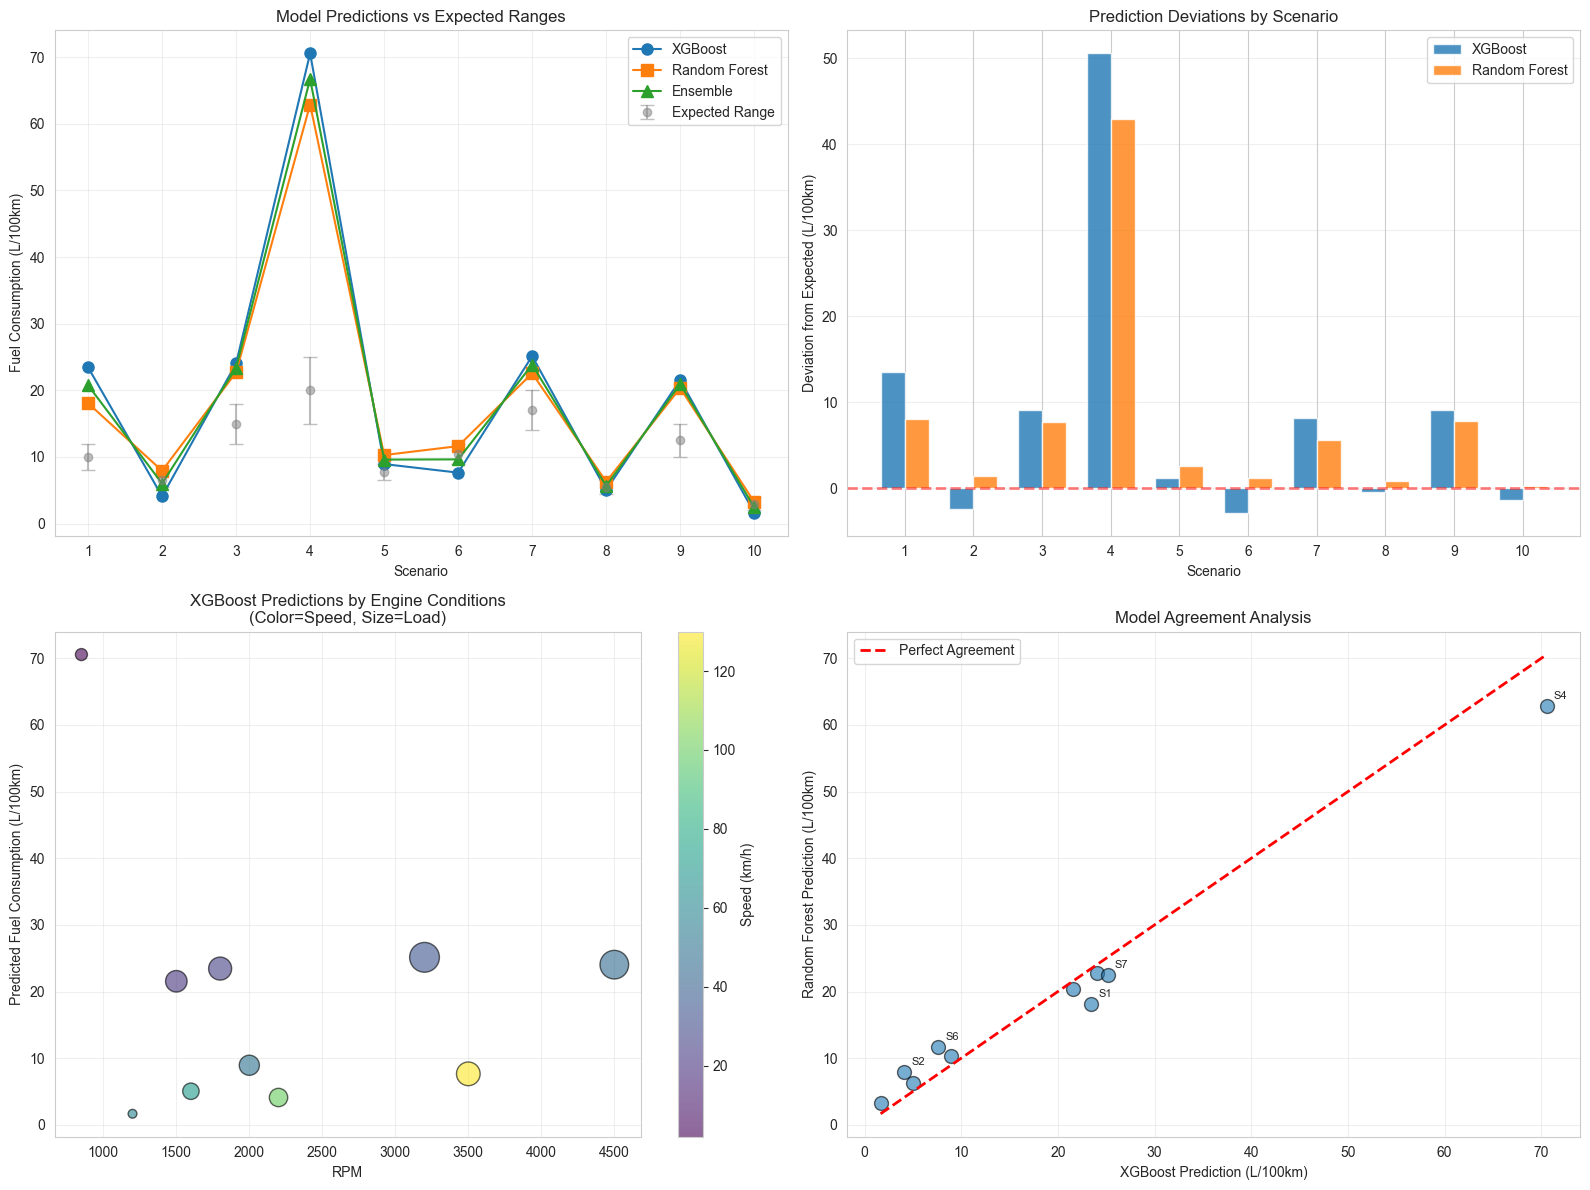


📊 Evaluation visualizations saved as 'scenario_evaluation_results.png'

💾 Detailed results saved to 'scenario_evaluation_results.csv'


In [26]:
test_scenarios = create_realistic_test_scenarios()

# Evaluate models on scenarios
evaluation_results = evaluate_models_on_scenarios(
    test_scenarios, 
    xgb_model, 
    rf_model, 
    scaler, 
    features
)

# Display detailed results
detailed_results = display_detailed_evaluation(evaluation_results)

# Visualize results
visualize_scenario_results(evaluation_results)

# Save results to CSV
evaluation_results.to_csv('scenario_evaluation_results.csv', index=False)
print("\n💾 Detailed results saved to 'scenario_evaluation_results.csv'")